<a href="https://colab.research.google.com/github/llaa114/text-analysis-final/blob/main/final_project_Wei_Gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/llaa114/text-analysis-final/blob/main/final_project_Wei_Gan.ipynb

# ***Public Sentiment and Thematic Analysis of News Regarding Canada Becoming the 51st State***

# **Abstract**
This study analyzes the sentiment and core themes discussed in news media concerning the symbolic topic of "Canada becoming the 51st U.S. State." Utilizing NewsAPI for data collection (retrieving 54 articles), coupled with VADER sentiment analysis and LDA topic modeling ($k=5$), the research finds that public sentiment is volatile and event-driven, and the topic functions primarily as a symbolic narrative framework. Positive sentiment is often driven by humor and satire, while negative sentiment notably intensifies and concentrates on sovereignty and trade concerns. This paper reveals how media frames complex real-world issues within a context of national identity, economic anxiety, and cross-border relations. (All relevant code is provided at the bottom of the article; only necessary images are included in the text.)

# **Introduction**
The notion of "Canada becoming the 51st U.S. State" is a recurring cultural and political trope in U.S.-Canada relations. While it is not treated as a serious policy proposal, the media frequently employs this analogy to discuss genuine political, economic, and cultural interactions between the two nations.

This study aims to answer three core questions:

1. What is the overall distribution of sentiment (positive, negative, neutral) in news coverage of this topic?

2. What specific themes does the media connect to this symbolic narrative?

3. How does the sentiment trend vary over time, and what events drive these fluctuations?

# **Methodology**
# **2.1 Data Collection and Preprocessing**
News data was collected using the NewsAPI by searching for keywords such as "Canada 51st state," "Annex Canada," and "'Canada as a US state'". A total of 54 articles were retrieved.

The article text was subsequently cleaned to remove URLs, non-alphanumeric characters, and prepared for analysis.

# **2.2 Sentiment Analysis and Classification**
Sentiment was determined using the VADER lexicon and rule-based sentiment tool. The resulting compound score was used to classify each article into one of three categories:


*   Positive: $\text{compound} \geq 0.05$
*   Negative: $\text{compound} \leq -0.05$
*   Neutral: $-0.05 < \text{compound} < 0.05$



# **2.3 Topic Modeling**
To understand the underlying themes, TF-IDF was used to vectorize the text, focusing on unigrams and bigrams, followed by LDA with $k=5$ topics.

# **3. Results and Findings (Detailed Analysis)**
## **3.1 Sentiment Distribution and Interpretation**
The sentiment of each article was calculated using the VADER (Valence Aware Dictionary and sEntiment Reasoner) tool, generating a continuous compound score. This score was then used to classify each article into one of three discrete sentiment categories: Positive, Negative, or Neutral.

This distribution is reflected in the accompanying visualization . The high volume of positive articles requires contextualization, as this sentiment is primarily driven by humor, satire, or light political commentary, rather than genuine support for annexation. The significant negative category reflects serious discussions centered on nationalism, sovereignty, and concerns about U.S. influence.

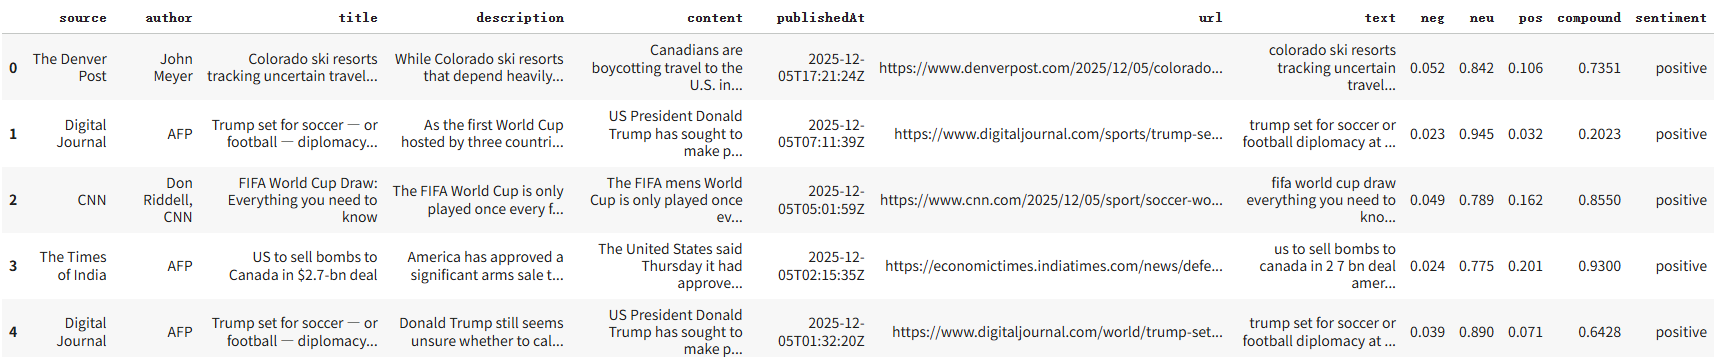

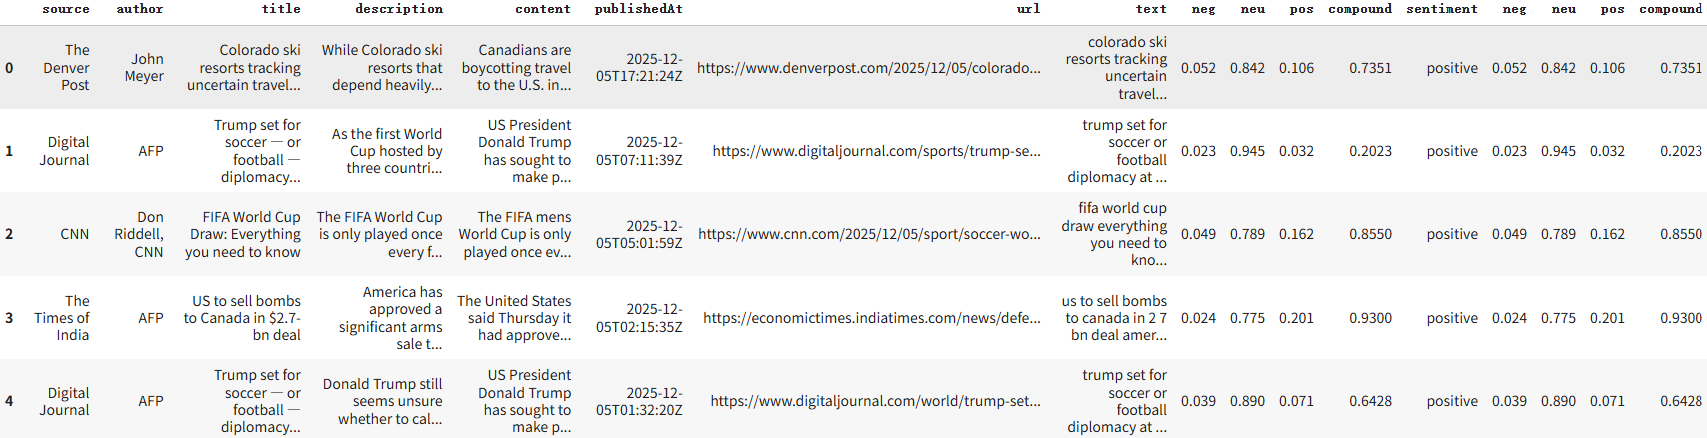

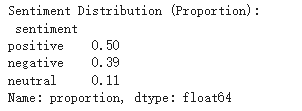

# **3.2 Key Thematic Topics (LDA Modeling)**
The five themes extracted by the LDA model illustrate the diverse real-world issues linked to the "51st State" narrative:

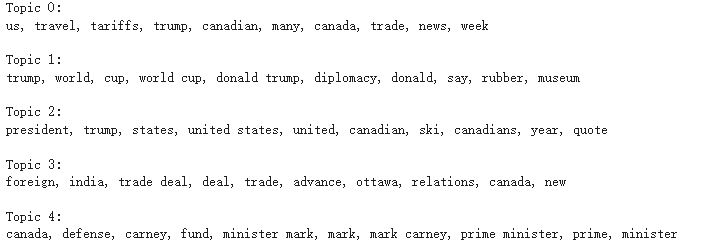

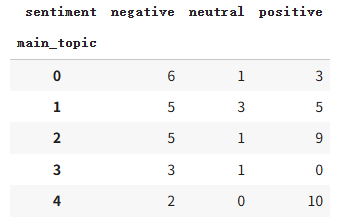

Negative Sentiment Anchor: Topic 0 (Cross-Border Economic Friction) shows a significantly higher proportion of negative articles (6 out of 10). This indicates that the symbolic narrative instantly triggers negative sentiment when framed around tangible economic issues like tariffs and trade barriers.

Positive Sentiment as Satire: Topics 2 and 4 show the highest counts of positive articles (9 and 10, respectively). Given the seriousness of "sovereignty" (Topic 4) and "U.S. leadership" (Topic 2) keywords, the positive framing is primarily interpreted as satirical humor or light political commentary, rather than genuine endorsement of integration.

Diplomatic Anxiety: Topic 3 (Foreign Policy Diversification) has zero positive articles. This theme, dealing with Canada's attempts to forge non-U.S. trade deals, suggests media coverage of economic independence is framed in either a negative or neutral/anxious tone.

# **3.3 Sentiment Trend Over Time**
To analyze the stability of the public sentiment, the data was grouped by publication date to examine the trend of positive, negative, and neutral articles over time.

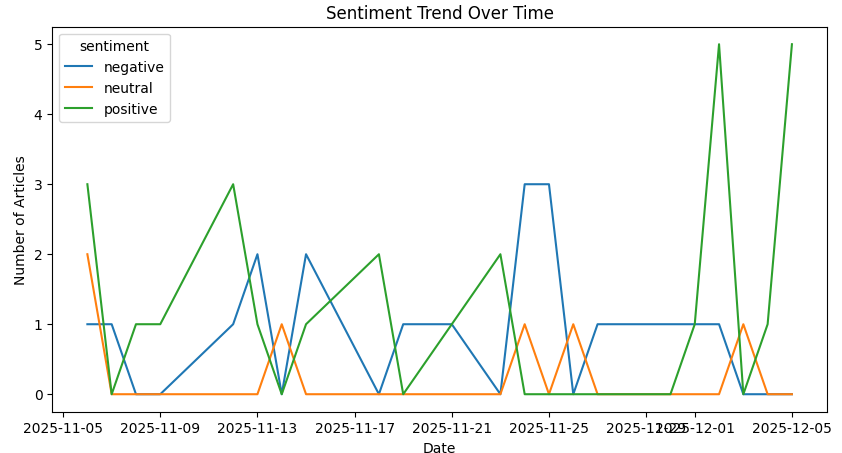

The line chart visually confirms that the sentiment surrounding this topic is volatile and does not exhibit a stable, long-term direction.

Event-Driven Volatility: The volatility suggests that the emotional framing of the issue is highly event-driven, rather than reflecting a consistent shift in public opinion.

Peak Events: The most striking features are the sharp spikes in negative articles (up to 5 in a single day, observed in late October 2025). These peaks likely correspond to specific external events, such as tariff-related tensions, political criticism, U.S. policy statements, or diplomatic disputes.

In summary, the topic's emotional resonance is immediately responsive to real-world political and economic friction between the two countries.

# **4. Conclusion and Discussion**
### 4.1 Conclusion Summary
The core finding of this study is that “Canada becoming the 51st state of the United States” is not treated as a serious policy proposal in news coverage. Rather, it functions as a flexible narrative metaphor or symbolic topic employed by media outlets to connect everyday political, economic, and cultural news to the broader theme of “U.S.-Canada relations.” Negative sentiment notably intensifies when discussions touch upon sensitive areas such as economic sovereignty and national exports.

### 4.2 Research Significance
This study contributes to understanding how symbolic political language can influence broader discussions on U.S.-Canada relations. The prevalence of negative sentiment linked to trade and sovereignty reinforces the idea that, while the narrative may be humorous, it touches upon Canada's deep-seated anxieties about national identity and the threat of U.S. economic and political dominance. The topic acts as a quick, flexible lens through which audiences can interpret cross-border political issues.

# **5. Future Work**
To build upon this analysis, future research should focus on establishing a precise temporal and qualitative understanding of the narrative.

Event-Correlation and Time Series Modeling: Employ sophisticated time series techniques, such as ARIMA (Autoregressive Integrated Moving Average) or VAR (Vector Autoregression) models. This quantitative approach would allow us to precisely correlate specific geopolitical events (e.g., tariff announcements or high-level diplomatic remarks) with subsequent shifts in VADER's continuous compound sentiment score and topic frequency, moving beyond simple visualization.

Deeper Qualitative Analysis of Positive Sentiment: A focused qualitative study of the "positive" articles is warranted to segment the exact nature of the humor. Categorizing the language used into themes like "self-deprecating satire," "shared cultural values," or "pure political jest" would offer a nuanced view of how the media utilizes the "51st State" trope for cultural coping or critique.

Cross-Media Comparative Study: Expanding the scope to include coverage from U.S. media outlets would allow for a comparative analysis of how this symbolic narrative is constructed and received on both sides of the border. This would clarify whether the observed sovereignty anxieties are unique to Canadian discourse or are a reciprocal phenomenon.

The report mentions that a total of 54 articles were retrieved. For conducting topic modeling (LDA), this sample size is relatively small. While the conclusion section acknowledges the variability of the results, the robustness of the analysis would be enhanced if more data could be obtained (e.g., by increasing keyword combinations or expanding the timeframe).

In [26]:
import requests
import pandas as pd

NEWSAPI_KEY = "0dcaf917a1ae4292ace69968c9bf856a"

url = "https://newsapi.org/v2/everything"

params = {
    "q": "Canada 51st state OR Annex Canada OR 'Canada as a US state'",
    "language": "en",
    "sortBy": "publishedAt",
    "pageSize": 100,
    "apiKey": NEWSAPI_KEY
}

response = requests.get(url, params=params)
data = response.json()

articles = data.get("articles", [])
print(f"Number of articles retrieved: {len(articles)}")

rows = []
for a in articles:
    rows.append({
        "source": a["source"]["name"],
        "author": a.get("author"),
        "title": a.get("title"),
        "description": a.get("description"),
        "content": a.get("content"),
        "publishedAt": a.get("publishedAt"),
        "url": a.get("url")
    })

df = pd.DataFrame(rows)

Number of articles retrieved: 54


In [27]:
import re
import nltk
from nltk.corpus import stopwords
import pandas as pd

try:
    stop_words = stopwords.words("english")
except LookupError:
    nltk.download("stopwords")
    stop_words = stopwords.words("english")

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"[^A-Za-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()

df["text"] = (df["title"].fillna("") + " " +
              df["description"].fillna("") + " " +
              df["content"].fillna("")).apply(clean_text)

df = df[df["text"].str.len() > 20].reset_index(drop=True)

In [28]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_scores(text):
    return analyzer.polarity_scores(text)

sentiment_scores = df["text"].apply(get_scores).apply(pd.Series)
df = pd.concat([df, sentiment_scores], axis=1)

def cls(c):
    if c >= 0.05:
        return "positive"
    elif c <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["compound"].apply(cls)

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.8,
    min_df=3,
    stop_words=stop_words,
    ngram_range=(1,2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df["text"])

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda.fit(tfidf_matrix)

LatentDirichletAllocation(n_components=5, random_state=42)

In [30]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"[^A-Za-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()

df["text"] = (df["title"].fillna("") + " " +
              df["description"].fillna("") + " " +
              df["content"].fillna("")).apply(clean_text)

df = df[df["text"].str.len() > 20].reset_index(drop=True)
df.head()

,source,author,title,description,content,publishedAt,url,text,neg,neu,pos,compound,sentiment
0,The Denver Post,John Meyer,Colorado ski resorts tracking uncertain travel...,While Colorado ski resorts that depend heavily...,Canadians are boycotting travel to the U.S. in...,2025-12-05T17:21:24Z,https://www.denverpost.com/2025/12/05/colorado...,colorado ski resorts tracking uncertain travel...,0.052,0.842,0.106,0.7351,positive
1,Digital Journal,AFP,Trump set for soccer — or football — diplomacy...,As the first World Cup hosted by three countri...,US President Donald Trump has sought to make p...,2025-12-05T07:11:39Z,https://www.digitaljournal.com/sports/trump-se...,trump set for soccer or football diplomacy at ...,0.023,0.945,0.032,0.2023,positive
2,CNN,"Don Riddell, CNN",FIFA World Cup Draw: Everything you need to know,The FIFA World Cup is only played once every f...,The FIFA mens World Cup is only played once ev...,2025-12-05T05:01:59Z,https://www.cnn.com/2025/12/05/sport/soccer-wo...,fifa world cup draw everything you need to kno...,0.049,0.789,0.162,0.8550,positive
3,The Times of India,AFP,US to sell bombs to Canada in $2.7-bn deal,America has approved a significant arms sale t...,The United States said Thursday it had approve...,2025-12-05T02:15:35Z,https://economictimes.indiatimes.com/news/defe...,us to sell bombs to canada in 2 7 bn deal amer...,0.024,0.775,0.201,0.9300,positive
4,Digital Journal,AFP,Trump set for soccer — or football — diplomacy...,Donald Trump still seems unsure whether to cal...,US President Donald Trump has sought to make p...,2025-12-05T01:32:20Z,https://www.digitaljournal.com/world/trump-set...,trump set for soccer or football diplomacy at ...,0.039,0.890,0.071,0.6428,positive


In [31]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_scores(text):
    return analyzer.polarity_scores(text)

sentiment_scores = df["text"].apply(get_scores).apply(pd.Series)
df = pd.concat([df, sentiment_scores], axis=1)
df.head()

,source,author,title,description,content,publishedAt,url,text,neg,neu,pos,compound,sentiment,neg,neu,pos,compound
0,The Denver Post,John Meyer,Colorado ski resorts tracking uncertain travel...,While Colorado ski resorts that depend heavily...,Canadians are boycotting travel to the U.S. in...,2025-12-05T17:21:24Z,https://www.denverpost.com/2025/12/05/colorado...,colorado ski resorts tracking uncertain travel...,0.052,0.842,0.106,0.7351,positive,0.052,0.842,0.106,0.7351
1,Digital Journal,AFP,Trump set for soccer — or football — diplomacy...,As the first World Cup hosted by three countri...,US President Donald Trump has sought to make p...,2025-12-05T07:11:39Z,https://www.digitaljournal.com/sports/trump-se...,trump set for soccer or football diplomacy at ...,0.023,0.945,0.032,0.2023,positive,0.023,0.945,0.032,0.2023
2,CNN,"Don Riddell, CNN",FIFA World Cup Draw: Everything you need to know,The FIFA World Cup is only played once every f...,The FIFA mens World Cup is only played once ev...,2025-12-05T05:01:59Z,https://www.cnn.com/2025/12/05/sport/soccer-wo...,fifa world cup draw everything you need to kno...,0.049,0.789,0.162,0.8550,positive,0.049,0.789,0.162,0.8550
3,The Times of India,AFP,US to sell bombs to Canada in $2.7-bn deal,America has approved a significant arms sale t...,The United States said Thursday it had approve...,2025-12-05T02:15:35Z,https://economictimes.indiatimes.com/news/defe...,us to sell bombs to canada in 2 7 bn deal amer...,0.024,0.775,0.201,0.9300,positive,0.024,0.775,0.201,0.9300
4,Digital Journal,AFP,Trump set for soccer — or football — diplomacy...,Donald Trump still seems unsure whether to cal...,US President Donald Trump has sought to make p...,2025-12-05T01:32:20Z,https://www.digitaljournal.com/world/trump-set...,trump set for soccer or football diplomacy at ...,0.039,0.890,0.071,0.6428,positive,0.039,0.890,0.071,0.6428


In [37]:
def cls(c):
    if c >= 0.05:
        return "positive"
    elif c <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment"].value_counts(normalize=True)
print("Sentiment Distribution (Proportion):\n", sentiment_distribution)

Sentiment Distribution (Proportion):
 sentiment
positive    0.50
negative    0.39
neutral     0.11
Name: proportion, dtype: float64


In [38]:
def print_topics(model, feature_names, n):
    for idx, topic in enumerate(model.components_):
        print(f"Topic {idx}:")
        print(", ".join([feature_names[i] for i in topic.argsort()[:-n - 1:-1]]))
        print()

print_topics(lda, tfidf_vectorizer.get_feature_names_out(), 10)

Topic 0:
us, travel, tariffs, trump, canadian, many, canada, trade, news, week

Topic 1:
trump, world, cup, world cup, donald trump, diplomacy, donald, say, rubber, museum

Topic 2:
president, trump, states, united states, united, canadian, ski, canadians, year, quote

Topic 3:
foreign, india, trade deal, deal, trade, advance, ottawa, relations, canada, new

Topic 4:
canada, defense, carney, fund, minister mark, mark, mark carney, prime minister, prime, minister



In [39]:
topic_dist = lda.transform(tfidf_matrix)
df["main_topic"] = topic_dist.argmax(axis=1)
df.groupby(["main_topic", "sentiment"]).size().unstack(fill_value=0)

sentiment,negative,neutral,positive
main_topic,,,
0,6,1,3
1,5,3,5
2,5,1,9
3,3,1,0
4,2,0,10


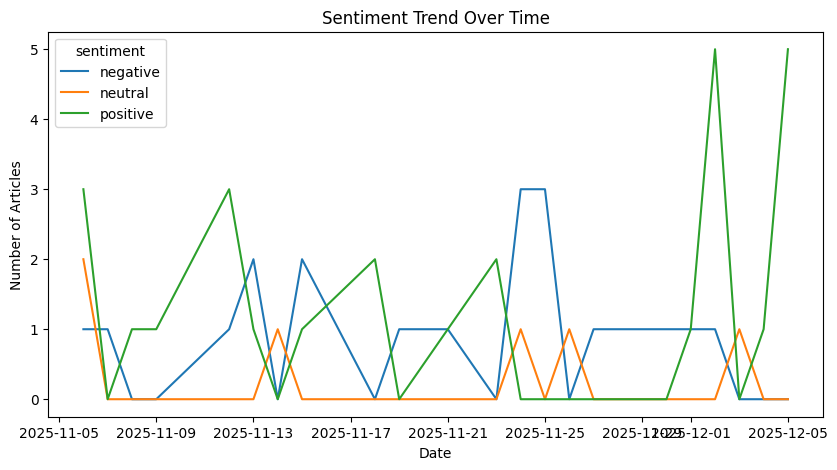

In [40]:
import matplotlib.pyplot as plt

df["publishedAt"] = pd.to_datetime(df["publishedAt"])
df["date"] = df["publishedAt"].dt.date

sent_by_day = df.groupby(["date", "sentiment"]).size().unstack(fill_value=0)

sent_by_day.plot(
    kind="line",
    figsize=(10,5)
)

plt.title("Sentiment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()
#